In [1]:
import os
os.chdir("./..")

from PVDatasetWithHistory import PVDatasetWithHistory

ds = PVDatasetWithHistory(r"C:\Users\peter\Repos\ENFIELD-data\processed_unpack\nwp_0h", previous_days=5, split="test")

In [3]:
from models.ADRInspired import ADRInspired as ADR
from utils.config import load_config
import torch

config = load_config("./config/ADR.yaml")
ADR_fit = ADR(config)
ADR_fit.load_state_dict(torch.load(r"C:\Users\peter\Repos\ENFIELD-PIML\checkpoints\PV-PIML\fit_normalized\epoch=7-step=32768.ckpt", weights_only=False)["state_dict"])

<All keys matched successfully>

In [171]:
from models.PVUNet import PVUNet

config = load_config("./config/PVUNet.yaml")
PVUNet_fit = PVUNet(config)
PVUNet_fit.load_state_dict(torch.load(r"C:\Users\peter\Repos\ENFIELD-PIML\checkpoints\PV-PIML\GHI_only\last-v2.ckpt", weights_only=False)["state_dict"])

<All keys matched successfully>

In [184]:
metadata

{'system_size': np.int64(2340),
 'latitude': np.float64(51.0333),
 'longitude': np.float64(4.4667),
 'elevation': np.float64(3.589486122131348),
 'country': 'Belgium',
 'installation': np.int64(69631),
 'date': '2020-02-23'}

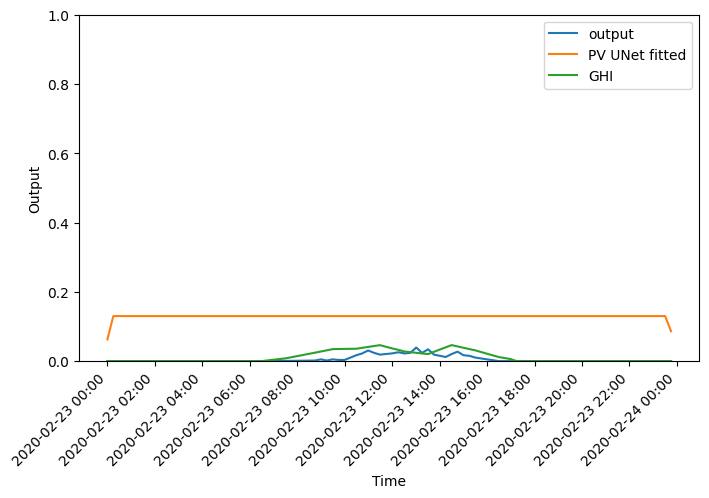

In [183]:
import torch
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates

import random

x, y, metadata = ds[random.randint(0, len(ds)-1)]
timestamps = x['unix_timestamps'].squeeze()
ghi = x['ghi'].squeeze()
metadata_tensors = {}
for key in list(x.keys()):
    x[key] = x[key].unsqueeze(0)
    if key != 'ghi':
        del x[key]

y_hat = PVUNet_fit(x).squeeze()
fitted_prediction = y_hat.detach().numpy()

#y_hat = model_default([t.unsqueeze(0) for t in x], metadata_tensors)
#default_prediction = y_hat.detach().numpy()

fig, ax = plt.subplots(1, 1, figsize=(8, 4.5))
ax.plot(pd.to_datetime(timestamps, unit="s"), y, label="output")
ax.plot(pd.to_datetime(timestamps, unit="s"), fitted_prediction, label="PV UNet fitted")
ax.plot(pd.to_datetime(timestamps, unit="s"), ghi / 1000, label="GHI")
#ax.plot(pd.to_datetime(x['unix_timestamps'][0], unit="s"), default_prediction[0], label="ADR default")
ax.set_xlabel("Time")
ax.set_ylabel("Output")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d %H:%M"))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
plt.xticks(rotation=45, ha='right')
ax.set_ylim(0,1)
plt.show()